<h1><center>Graded practical work (12h)</center></h1>

# Students Names : 
**Labastie Killian   
Karch Tom**

## Summary 
- [1. Introduction](#1-Introduction)
  - [1.1 Objective](#1.1-objective)
  - [1.2 Recall : the POMDP model](#1.2-the-pomdp-model)
  - [1.3 Provided library](#1.3-provided-library)
- [2. The firefighter robot game](#2-the-firefighter-robot-game)
  - [2.1 Experiments conducted in the lab](#2.1-experiments-conducted-in-the-lab)
  - [2.2 Mission scoring](#2.2-mission-scoring)
  - [2.3 Dataset and markers description](#2.3-dataset-and-markers-description)
- [3. Practical work tasks](#3-practical-work-tasks)
  - [Task 1 : Defining the POMDP model](#task-1--defining-the-pomdp-model)
    - [Task 1.1 : Define the POMDP observation function](#task-11--define-the-pomdp-observation-function)
    - [task 1.2 : Define the POMDP reward function](#task-12--define-the-pomdp-reward-function)
  - [Task 2 : POMDP model solving and evaluation](#task-2-pomdp-model-solving-and-evaluation)
    - [Task 2.1 : POMDP model description using the Cassandra format](#task-21-pomdp-model-description-using-the-cassandra-format)
    - [Task 2.2 : POMDP model solving using the customized pypomdp library](#task-22-pomdp-model-solving-using-the-customized-pypomdp-library)
    - [Task 2.3 : POMDP model evaluation in simulation](#task-23-pomdp-model-evaluation-in-simulation)
    - [Task 2.4 : Quantitative and qualitative comparison with the random policy used during experiments](#task-24--quantitative-and-qualitative-comparison-with-the-random-policy-used-during-experiments)
  - [Task 3 : Refining the POMDP model](#task-3--refining-the-pomdp-model)
    - [Task 3.1 : Revise task 1.1.3 to separate your dataset in 2 depending on the robot operation mode](#task-31-revise-task-113-to-separate-your-dataset-in-two-datasets-depending-on-the-robot-operation-mode)
    - [Task 3.2 : Revise tasks 1.1.4 and 1.1.5](#task-32-revise-tasks-114-and-115-to-train-a-classifier-per-dataset-and-then-extract-their-confusion-matrix)
    - [Task 3.3 : Revise task 2.1](#task-33-revise-task-21-to-define-your-pomdp-in-the-cassandra-file-format)
    - [Task 3.4 : Revise tasks 2.2 and 2.3](#task-34-revise-tasks-22-and-23)
- [4. Champions' Question](#4-champion's-question)

# **1. Introduction**

## **1.1 Objective**

Set up a simple yet effective POMDP model in order to drive human-machine interaction in the Firefighter Robot Game study case. 

![POMDP_for_HRI.png](./figures/POMDP_for_HRI_compressed.png)

This POMDP model will be based on a dataset that has been collected during an experiment and that is provided to you.

## **1.2 Recall: the POMDP model**

If you need a reminder about POMDPs definitions and algorithms get a look into **"Recalling_POMDPs.ipynb"**

## **1.3 Provided library**
The PyPOMDP library (see https://github.com/namoshizun/PyPOMDP) is provided with this notebook. 

This library proposes two state-of-the-art algorithms, PBVI and POMCP (do not hesitate to get a look in the Caroline's slides courses). However, this library has been customized with several additional features that will be very useful for this practical work.

For instance, the library now save a Value Function parametrized by $\alpha$-vectors, in a file. This can be then reloaded to simulate the policy in order to evaluate futur gains, or in order to replay an experiment.

In this practical work course we will mainly use the implementation of PBVI.

# **2. The Firefighter Robot Game**

## **2.1 Experiments conduted in the lab**
During lab experiments, 18 volunteers equipped with physiological sensors have played the Firefigther Robot Game.
http://robot-isae.isae.fr

![sujet_compressed.jpg](figures/sujet_compressed.jpg)

Each participant followed an experimental protocol in which 4 missions are played. Please see the FireFigther game presentation for more details.

![procedureEnglish_compressed.png](figures/procedureEnglish_compressed.png)


## **2.2. Mission scoring**

The number of extinguished fires allowed to quantify how well a mission has been performed. We could define two performance group using the median score as a threshold to obtain a balanced dataset. Each mission was then labeled as: 0 for low scoring mission group (low performance); and 1 for high scoring mission group (high performance).


## **2.3. Dataset and markers description**

Two datasets are provided:
1. A labeled dataFrame including preprocessed markers for each 10-second time window, mission and participant
2. A labeled dataFrame gathering **averaged markers** results for each 10-second time window, mission, participant and robot operation mode


In [1]:
import pandas as pd
import numpy as np

# example :
# importing label dataset including preprocessed markers for each 10-second time window, mission and participant
# this dataset will be useful for classification purposes
df10labeled_data = pd.read_csv('./data/df10labeled_data.csv')
print(df10labeled_data)

# example:
# importing labeled dataset with averaged or summed markers results for each 
# 10-second time window, mission, participant and robot operation mode
averagedPMPVmode_w10_data = pd.read_csv('./data/averagedPMPVmode_w10_data.csv')
print(averagedPMPVmode_w10_data)


      subject  mission  mode         HR       HRV   nav  tank  space  trees  \
0        19.0      1.0   0.0  72.568940 -0.066819  14.0   0.0    0.0    0.0   
1        19.0      1.0   0.0  74.229865 -0.087446  18.0   2.0    0.0    0.0   
2        19.0      1.0   1.0  73.304826 -0.070724   9.0   5.0    0.0    0.0   
3        19.0      1.0   1.0  69.962687 -0.050697   0.0   8.0    0.0    0.0   
4        19.0      1.0   1.0  70.771408 -0.076950   0.0   7.0    0.0    1.0   
...       ...      ...   ...        ...       ...   ...   ...    ...    ...   
3586     40.0      4.0   1.0  69.767442 -0.041904   0.0  24.0    0.0    0.0   
3587     40.0      4.0   0.0  67.046597 -0.043276  12.0   8.0    0.0    0.0   
3588     40.0      4.0   0.0  69.549090 -0.044936  10.0  14.0    0.0    0.0   
3589     40.0      4.0   0.0  72.245635 -0.045260   6.0   8.0    1.0    0.0   
3590     40.0      4.0   1.0  71.564885 -0.048838   2.0   9.0    0.0    0.0   

      nbAOI1  ...  nbAOI4  nbAOI5  durAOI1   durAOI

In [2]:
# Fix sklearn/pyarrow DLL issue sur Windows
import os
import sys

# Éviter les problèmes pyarrow sans le bloquer complètement
os.environ['SKLEARN_SKIP_NETWORK_TESTS'] = '1'
os.environ['SKLEARN_ALLOW_THREADS'] = '1'

# Test direct des imports critiques
try:
    from sklearn.ensemble import RandomForestClassifier
    print("✓ RandomForestClassifier imported successfully")
except Exception as e:
    print(f"⚠️ sklearn import issue: {e}")
    raise

print("\n✅ sklearn environment ready!")

print("\n✅ sklearn environment ready!")

✓ RandomForestClassifier imported successfully

✅ sklearn environment ready!

✅ sklearn environment ready!


### markers description
* **subject** : identification number of the participant
* **mission** : identification number of the mission (1, 2, 3 or 4)
* **mode** : robot operation mode (0 for manual, 1 for autonomous)
* **HR** : average of the participant's heart-rate (on the 10sec window) 
* **normHR** : normalized participant's heart-rate (w.r.t. the rest period)
* **HRV** : normalized heart-rate variability (w.r.t. the rest period)
* **nav** : total number of keystrokes and cliks related with robot navigation control task in the 10sec window.
* **tank** : total number of  keystrokes/clicks realted with the external tank management task in the 10sec window.
* **space** : total number of times the space key was pressed in the 10sec window.
* **trees** : total number of trees on fire that are extinghised using the space keyboard in the 10sec window.
* **nbAOI1** : total number of eye fixations in the AOI (Areas-Of-Interest) number 1 (same for the others).
* **durAOI1** : total duration of fixations performed in the AOI number 1 (same for the others)
* **tank_local_score** : how much the external tank level has increased/decreased in the last 10s.
* **nbt_trees_mode** : total number of extinguished trees per operation mode
* **label**: {0,1} boolean indicating if the final mission score is good (1) or bad (0). Note that in this work we will consider that it reflects the mental state of the human operator: 1 for $e$ (engaged / performant) and 0 for $ne$ (not engaged / not performant).

# **3. Practical Work Tasks**

## **Task 1. Defining the POMDP model**

As our goal is to drive (i.e. control) the interaction between the human operator and the robot in function of the human operator engagement (cf. presentation):

1. We define the state space as $S = S_h$, where $S_h = \{e, ne\}$, to express the human partially observable mental state of (a correct) engagement ($e$) or the absence of (a correct) engagement ($ne$). Note that this last mental state encapsulates disengaged and over-engaged cases, in which participants performed badly.
2. We define the action space as $A = \{manual, auto\}$, representing the possible decisions of our POMDP agent about which robot operation mode (manual or autonomous mode) should be used.
3. We define the observation space as $\Omega =  \{oe, one\}$, that are the possible predictions of a classifier trained to detect human engagement based on available behavioral and physiological data.

The transition function is defined as $p(s, a, s') = Pr(s' \mid s,a) = \left \{ \begin{array}{cc} 1 - \epsilon & \mbox{if } s=s'\\ \epsilon & \mbox{ otherwise } \end{array} \right.$. Note that the dynamics of the operator engagement in the task is rougly approached using the fact that an "engaged" human operator remains "engaged" with a small probability ($\epsilon$) for changing its mental state to "not engaged".

**It will be your job to define of the observation $o()$ and the reward $r()$ functions. For that, you may make use of the provided behavioral and physiological data.**

We notice that the time step $t$ in our POMDP model refers to a 10-second time window. In other words, the POMDP agent plays an action every 10s.

### **Task 1.1. Define the POMDP observation function**

To achieve this step, proceed by chosing features and use them to train and test a classifier. 

The output of this classifier will be the prediction (observation) about the human operator engagement based on data. As explained, ET, ECG and HAI markers are provided. **It is your job to choose which markers are relevant to be used as features.**

In order to check on markers relevance, we suggest you perform decriptive and statistical analysis.

#### **Task 1.1.1. Descriptive data analysis**

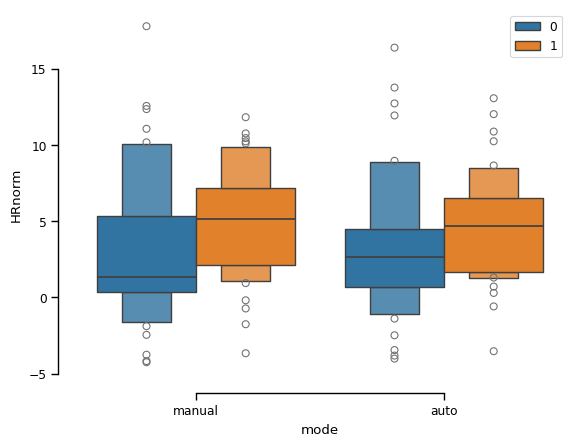

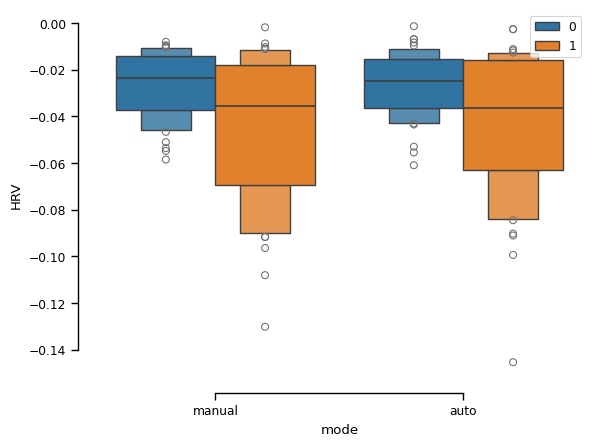

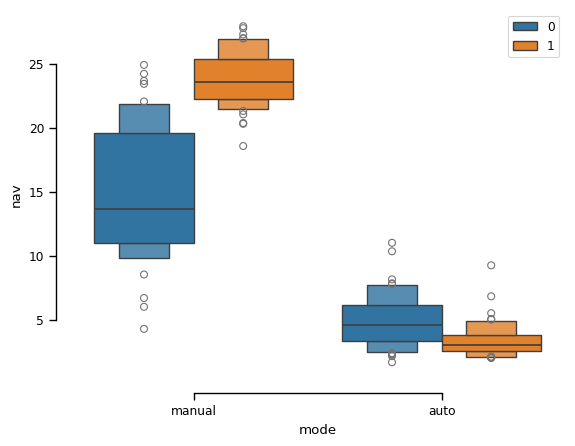

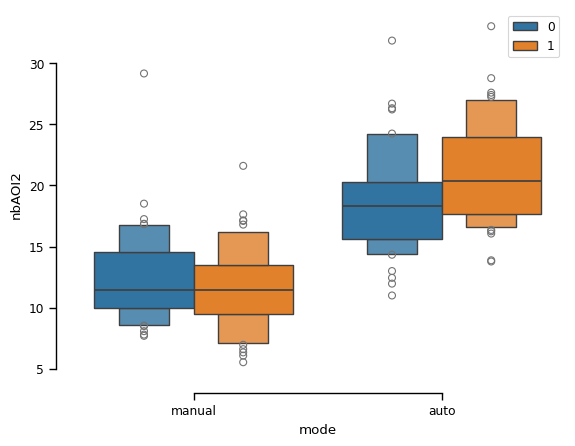

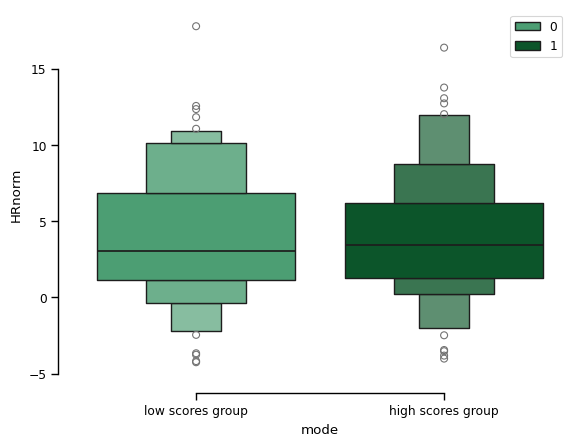

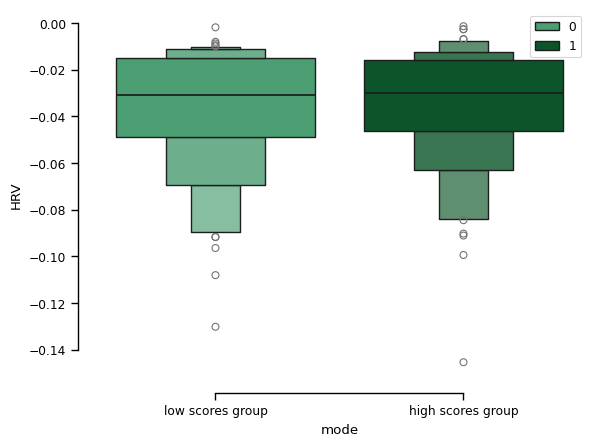

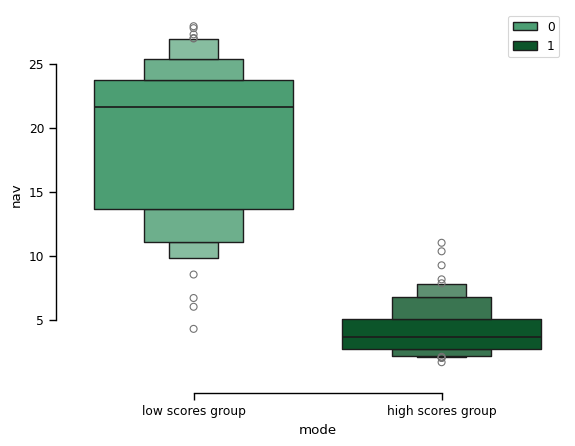

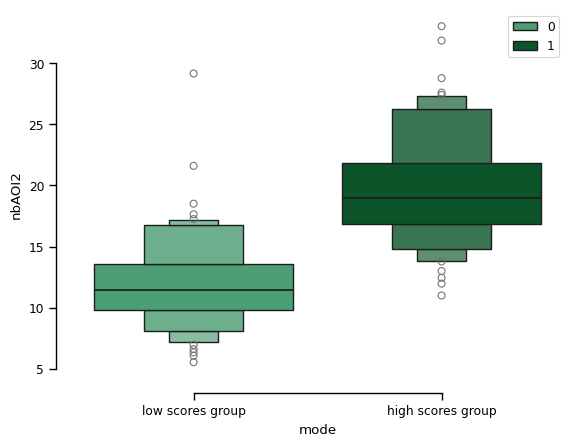

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

######################################################################
### Defining some useful plotting function for you
def plotting_data_per_mode(data, xstr, ystr):
    palette=sorted(sns.color_palette("BuGn", 10), reverse=True)
    palette = [palette[6], palette[9]]
    sns.set_context("paper", font_scale=1, rc={"lines.linewidth": 2.5})
    sns.boxenplot(x=xstr, y=ystr, hue="mode", palette=palette, linewidth=1, data=dfaveraged_data)
    #plt.ylim([-1, 30])
    plt.xticks([0, 1], ['low scores group', 'high scores group'])
    sns.despine(offset=10, trim=True)
    plt.legend(loc='best')
    
def plotting_data_per_perfgroup(data, xstr, ystr):
    palette=sorted(sns.color_palette("BuGn", 10), reverse=True)
    palette = [palette[6], palette[9]]
    sns.set_context("paper", font_scale=1, rc={"lines.linewidth": 2.5})
    #sns.boxenplot(x=xstr, y=ystr, hue="label", palette=palette, linewidth=1, data=dfaveraged_data)
    sns.boxenplot(x=xstr, y=ystr, hue="label", linewidth=1, data=dfaveraged_data)
    #plt.ylim([-1, 30])
    plt.xticks([0, 1], ['manual', 'auto'])
    sns.despine(offset=10, trim=True)
    plt.legend(loc='best')
    plt.show()
    

#######################################################################
# importing data
dfaveraged_data = pd.read_csv('./data/averagedPMPVmode_w10_data.csv')

## Plotting display examples
## Note these plots represent quantiles of the quantitative variables
## plotting operation mode x HRnorm grouped by the performance label
plotting_data_per_perfgroup(dfaveraged_data, "mode", "HRnorm")
plt.show()
#plt.clf()

## plotting operation mode x HRV grouped by the performance label
plotting_data_per_perfgroup(dfaveraged_data, "mode", "HRV")
plt.show()
#plt.clf()

## plotting operation mode x nav keystrokes grouped by the performance label
plotting_data_per_perfgroup(dfaveraged_data, "mode", "nav")
plt.show()
#plt.clf()

## plotting operation mode x nav keystrokes grouped by the performance label
plotting_data_per_perfgroup(dfaveraged_data, "mode", "nbAOI2")
plt.show()
#plt.clf()

### PLEASE CONTINUE DESCRIPTIVE STATISTICAL ANALYSIS
## use summary statistics from scipy.stats library

#on trace la même chose que précédemment mais en groupant par mode et label
plotting_data_per_mode(dfaveraged_data, "mode", "HRnorm")
plt.show()
#plt.clf()      
plotting_data_per_mode(dfaveraged_data, "mode", "HRV")
plt.show()
#plt.clf()
plotting_data_per_mode(dfaveraged_data, "mode", "nav")
plt.show()
#plt.clf()
plotting_data_per_mode(dfaveraged_data, "mode", "nbAOI2")
plt.show()
#plt.clf()      





#### **Draw conclusions for Task 1.1.1.**
<span style='color: green'> **Answer: Les graphiques exploratoires montrent que la variable HRnorm (rythme cardiaque normalisé) est en moyenne plus élevée pour les missions classées label = 1 (haute performance / engagement) que pour label = 0, et cette différence est visible dans les deux modes d’opération (manuel/auto). HRV présente des différences plus faibles. La variable nbAOI2 (nombre de fixations dans l’AOI 2) montre une interaction notable mode×label : en mode = auto les participants performants (label = 1) présentent davantage de fixations sur l’AOI2 que les non‑performants, ce qui suggère que l’attention visuelle dépend à la fois du mode et de l’engagement. nav et trees présentent aussi des patterns intéressants et peuvent être des candidats utiles pour la classification. En synthèse, HRnorm apparaît comme un candidat prioritaire pour prédire l’état d’engagement, tandis que nbAOI2 et nav sont des marqueurs complémentaires à considérer (éventuellement en entraînant des classifieurs séparés par mode ou en incluant mode comme feature).**  </span>

#### **Task 1.1.2. Statistical analysis**

To achieve this task, get a look on the data, and answer the following questions
* **Which are the markers significantly impacted by the human operator perf/engagement (POMDP observation)?**
* **Are the markers also impacted by the robot operation mode (POMDP action)?**

**For that, you have to formally define the null hypothesis (H0) and the alternative one (H1) for each statistical test**

**Remark 1 :** make use of ***Introduction to Statistics for Experimentations*** course (DNIA302) to achieve this step.

**Remark 2 :** note that the **averaged data file (averagedPMPVmode_w10_data) will be used for this analysis**. The 10-second time window data is averaged by participant, mission and operation mode. Additional columns appear, providing the total number of trees extinguished for each operation mode, as well as the performance/engagement label.

Note: you may need to restart the kernel to use updated packages.
Index(['HR', 'HRV', 'HRnorm', 'durAOI1', 'durAOI2', 'durAOI3', 'durAOI4',
       'durAOI5', 'mission', 'mode', 'nav', 'nbAOI1', 'nbAOI2', 'nbAOI3',
       'nbAOI4', 'nbAOI5', 'space', 'subject', 'tank', 'tank_local_score',
       'trees', 'nbt_trees_mode', 'label', 'modeperf', 'submission'],
      dtype='object')
#####################################################################
2-WAY ANOVA H1: HRV is impacted by the operation mode and the performance (label)
Overall model F( 3, 140) =  5.830, p =  0.0009

                            OLS Regression Results                            
Dep. Variable:                    HRV   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     5.830
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           0.000879
Time:                   

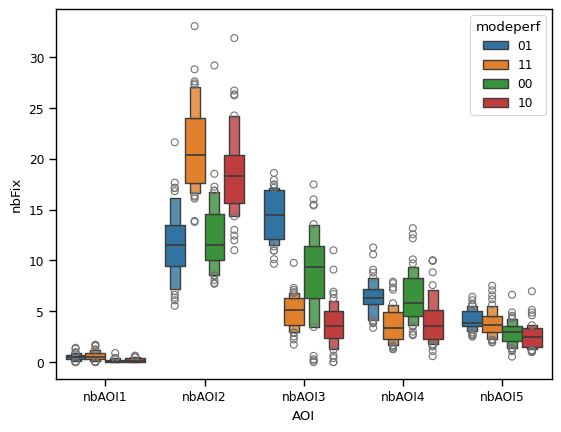

In [4]:
import pandas as pd
import numpy as np
import scipy.stats as stats
%pip install statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.anova import AnovaRM
from statsmodels.graphics.factorplots import interaction_plot
from statsmodels.stats.multicomp import MultiComparison, pairwise_tukeyhsd, tukeyhsd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

#########################
# Importing data
dfaveraged_data = pd.read_csv('./data/averagedPMPVmode_w10_data.csv')
#########################
# Creating groups "mode x label" for multiple comparison purposes 
dfaveraged_data['modeperf'] = dfaveraged_data['mode'].map(str) + dfaveraged_data['label'].map(str)
dfaveraged_data['submission'] = dfaveraged_data['subject'].map(str) + "_" + dfaveraged_data['mission'].map(str)
print(dfaveraged_data.columns)

#########################
# EXAMPLE 
# ANOVA considering performance group and robot operation mode
# NOTE: we have to assume that each mission is independent here because 
# some participants belong only to one performance group
# (in reality intra-subject sample are dependent)

# 1) We try to verify the hypothesis :
# H0 : HRV is not impacted by the operation mode nor the performance group (label)
# H1 : HRV is impacted by the operation mode or the performance group (label)
print("#####################################################################")
print("2-WAY ANOVA H1: HRV is impacted by the operation mode and the performance (label)")
HRVmodel = ols('HRV ~ C(mode)*C(label)', dfaveraged_data).fit()
print(f"Overall model F({HRVmodel.df_model: .0f},{HRVmodel.df_resid: .0f}) = {HRVmodel.fvalue: .3f}, p = {HRVmodel.f_pvalue: .4f}")
print()
print(HRVmodel.summary())
res = sm.stats.anova_lm(HRVmodel, typ= 2)
print()
print(res)

# perform multiple comparison (post-hoc Tukey HSD)
m_comp = MultiComparison(dfaveraged_data['HRV'], groups=dfaveraged_data['modeperf']).tukeyhsd(alpha=0.05)
print(m_comp)

##################################################
### PLEASE DO THE SAME ANALYSIS WITH HR JUST BELOW
print("#####################################################################")
print("2-WAY ANOVA H1: HR is impacted by the operation mode and the performance (label)")
HRmodel = ols('HR ~ C(mode)*C(label)', dfaveraged_data).fit()
print(f"Overall model F({HRmodel.df_model: .0f},{HRmodel.df_resid: .0f}) = {HRmodel.fvalue: .3f}, p = {HRmodel.f_pvalue: .4f}")
print()
print(HRmodel.summary())
res = sm.stats.anova_lm(HRmodel, typ= 2)
print()
print(res)

# perform multiple comparison (post-hoc Tukey HSD)
m_comp = MultiComparison(dfaveraged_data['HR'], groups=dfaveraged_data['modeperf']).tukeyhsd(alpha=0.05)
print(m_comp)

#################################################################
### NOW LET'S ANALYSE THE NUMBER OF FIXATIONS IN AOIs (nbFixAOIX)
# for instance:
# 2a) We try to verify the hypothesis : 
# H0 : the number of fixations is not affected by the AOI index nor the operation mode
# H1 : the number of fixations is affected by the AOI index or the operation mode
df = pd.melt(dfaveraged_data[["modeperf","mode","label","submission","subject","nbAOI1","nbAOI2","nbAOI3","nbAOI4","nbAOI5"]], 
             id_vars=["modeperf","submission","mode","label","subject"], 
             value_vars=["nbAOI1","nbAOI2","nbAOI3","nbAOI4","nbAOI5"])
df = df.rename(columns={'value': 'nbFix'})
df = df.rename(columns={'variable': 'AOI'})

# NOTE: we use a repeated measures ANOVA design because data is dependent within subjects and missions
res=AnovaRM(data=df,depvar="nbFix",subject="submission", within=["AOI","mode"]).fit()
print(res)

# 2b) We try to verify the hypothesis : 
# H0 : the number of fixations is not affected by the AOI index nor the operation mode nor the performance label
# H1 : the number of fixations is affected by the AOI index or the operation mode or the performance label
# NOTE: we can't use repeated measure ANOVA design in this case because:
# all the conditions aren't repeated within subjects
sns.boxenplot(x="AOI", y="nbFix", hue="modeperf", linewidth=1, data=df)
print("#####################################################################")
print("3-WAY ANOVA H1: nbFix is impacted by the AOI, the operation mode and the performance (label)")
nbFixModel = ols('nbFix ~ C(mode)*C(label)*C(AOI)', df).fit()
res = sm.stats.anova_lm(nbFixModel, typ= 3)
print(res)

# perform multiple comparison (post-hoc Tukey HSD)
df['modeperfAOI'] = df['mode'].map(str) + "_" + df['label'].map(str) + "_" + df['AOI'].map(str)
m_comp_crossAOIs = MultiComparison(df['nbFix'], groups=df['modeperfAOI']).tukeyhsd(alpha=0.05)
print(m_comp_crossAOIs)

###########################################################################
### PLEASE DO THE SAME ANALYSIS WITH THE AOIs FIXATION DURATIONS JUST BELOW
print("#####################################################################")
print("3-WAY ANOVA H1: Fixation duration is impacted by the AOI, the operation mode and the performance (label)")
# we do the same thing as before but with fixation durations instead of fixation counts
df = pd.melt(dfaveraged_data[["modeperf","mode","label","submission","subject","durAOI1","durAOI2","durAOI3","durAOI4","durAOI5"]], 
             id_vars=["modeperf","submission","mode","label","subject"], 
             value_vars=["durAOI1","durAOI2","durAOI3","durAOI4","durAOI5"])
df = df.rename(columns={'value': 'durFix'})
df = df.rename(columns={'variable': 'AOI'}) 

####################################################################################
### PLEASE DO THE SAME ANALYSIS WITH THE KEYSTROKES AND CLICKS (nav,tank) JUST BELOW
print("#####################################################################")
print("3-WAY ANOVA H1: nav keystrokes is impacted by the AOI, the operation mode and the performance (label)")
# we do the same thing as before but with nav keystrokes instead of fixation counts
df = pd.melt(dfaveraged_data[["modeperf","mode","label","submission","subject","nav"]], 
             id_vars=["modeperf","submission","mode","label","subject"], 
             value_vars=["nav"])
df = df.rename(columns={'value': 'navKeystrokes'})  





Task 1.1.2 - What do these plots represent?

1) Boxenplot grouped by mode
- x-axis: label (0/1). y-axis: HRnorm.
- color: mode (0 manual, 1 auto)
- If boxes differ by color, mode impacts HRnorm.


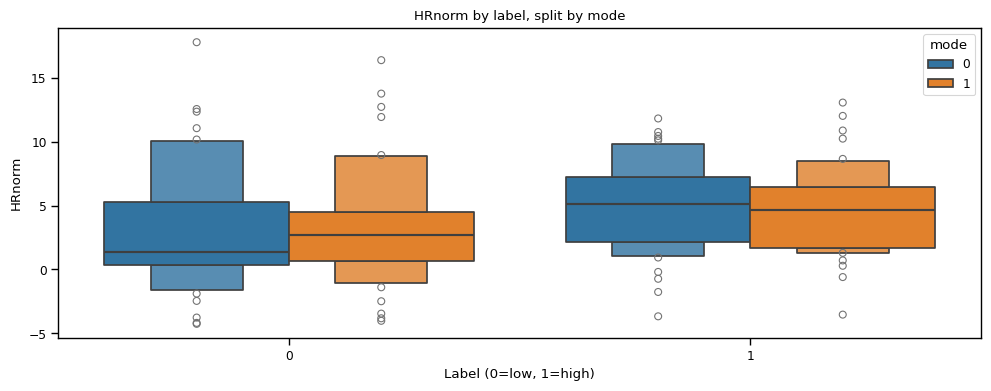


2) Boxenplot grouped by label
- x-axis: mode (0/1). y-axis: HRnorm.
- color: label (0 low, 1 high)
- If boxes differ by color, label impacts HRnorm.


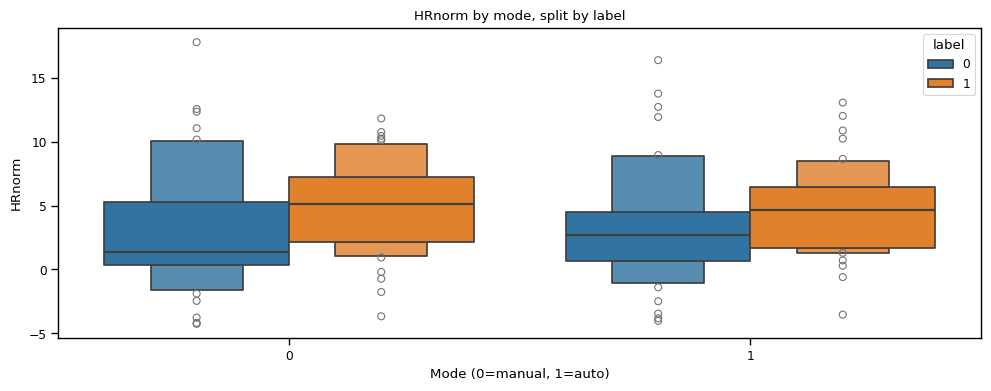


3) AOI plot (fixations by AOI, colored by mode+label)
- x-axis: AOI (nbAOI1..nbAOI5). y-axis: number of fixations.
- color: modeperf (00, 01, 10, 11).
- Look for big separation between 00 and 01 to see engagement effect.


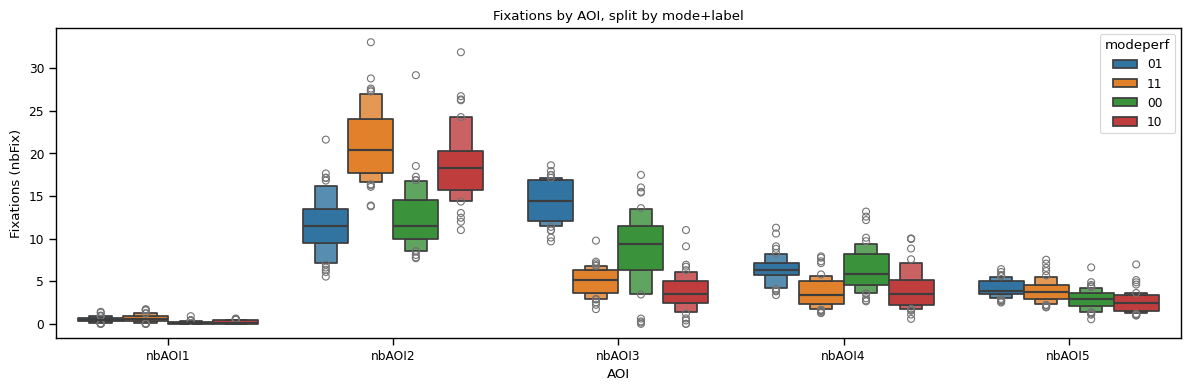


4) AOI plot (fixation durations by AOI, colored by mode+label)
- x-axis: AOI (durAOI1..durAOI5). y-axis: total fixation duration.
- color: modeperf (00, 01, 10, 11).
- Look for big separation between 00 and 01 to see engagement effect.


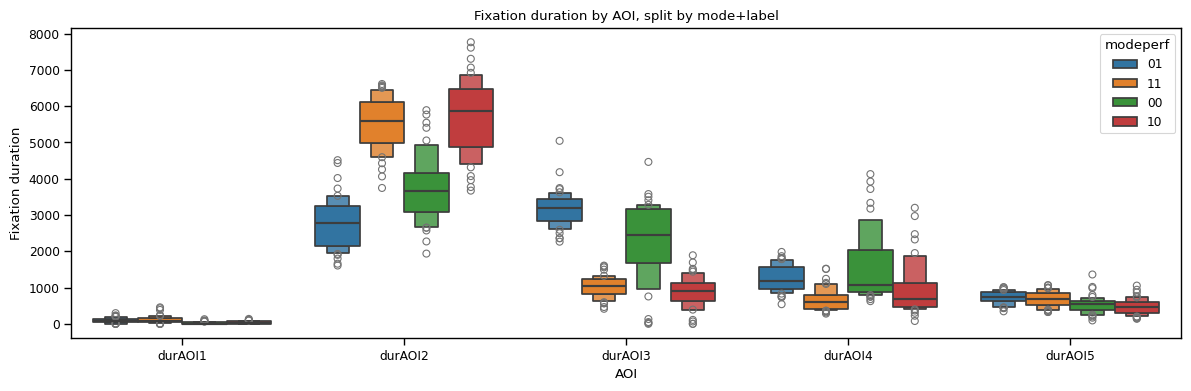


Summary:
- Big color separation => strong effect.
- Overlapping boxes => weak or no effect.
- AOIs with clear separation are good feature candidates.


In [5]:
# Task 1.1.2 - Plot interpretation helper (three key examples)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("Task 1.1.2 - What do these plots represent?")
print("=" * 80)

# Load data used in Task 1.1.2
_df = pd.read_csv('./data/averagedPMPVmode_w10_data.csv')
_df['modeperf'] = _df['mode'].map(str) + _df['label'].map(str)

# 1) Boxenplot: effect of mode for a given label (HRnorm example)
print("\n1) Boxenplot grouped by mode")
print("- x-axis: label (0/1). y-axis: HRnorm.")
print("- color: mode (0 manual, 1 auto)")
print("- If boxes differ by color, mode impacts HRnorm.")

plt.figure(figsize=(10, 4))
sns.boxenplot(x="label", y="HRnorm", hue="mode", data=_df)
plt.title("HRnorm by label, split by mode")
plt.xlabel("Label (0=low, 1=high)")
plt.ylabel("HRnorm")
plt.tight_layout()
plt.show()

# 2) Boxenplot: effect of label for a given mode (HRnorm example)
print("\n2) Boxenplot grouped by label")
print("- x-axis: mode (0/1). y-axis: HRnorm.")
print("- color: label (0 low, 1 high)")
print("- If boxes differ by color, label impacts HRnorm.")

plt.figure(figsize=(10, 4))
sns.boxenplot(x="mode", y="HRnorm", hue="label", data=_df)
plt.title("HRnorm by mode, split by label")
plt.xlabel("Mode (0=manual, 1=auto)")
plt.ylabel("HRnorm")
plt.tight_layout()
plt.show()

# 3) AOI plot: fixations by AOI with mode+label groups
print("\n3) AOI plot (fixations by AOI, colored by mode+label)")
print("- x-axis: AOI (nbAOI1..nbAOI5). y-axis: number of fixations.")
print("- color: modeperf (00, 01, 10, 11).")
print("- Look for big separation between 00 and 01 to see engagement effect.")

_df_aoi = pd.melt(
    _df[["modeperf", "mode", "label", "subject", "nbAOI1", "nbAOI2", "nbAOI3", "nbAOI4", "nbAOI5"]],
    id_vars=["modeperf", "mode", "label", "subject"],
    value_vars=["nbAOI1", "nbAOI2", "nbAOI3", "nbAOI4", "nbAOI5"],
    var_name="AOI",
    value_name="nbFix"
)

plt.figure(figsize=(12, 4))
sns.boxenplot(x="AOI", y="nbFix", hue="modeperf", data=_df_aoi)
plt.title("Fixations by AOI, split by mode+label")
plt.xlabel("AOI")
plt.ylabel("Fixations (nbFix)")
plt.tight_layout()
plt.show()

# 4) AOI plot: fixation durations by AOI with mode+label groups
print("\n4) AOI plot (fixation durations by AOI, colored by mode+label)")
print("- x-axis: AOI (durAOI1..durAOI5). y-axis: total fixation duration.")
print("- color: modeperf (00, 01, 10, 11).")
print("- Look for big separation between 00 and 01 to see engagement effect.")

_df_dur = pd.melt(
    _df[["modeperf", "mode", "label", "subject", "durAOI1", "durAOI2", "durAOI3", "durAOI4", "durAOI5"]],
    id_vars=["modeperf", "mode", "label", "subject"],
    value_vars=["durAOI1", "durAOI2", "durAOI3", "durAOI4", "durAOI5"],
    var_name="AOI",
    value_name="durFix"
)

plt.figure(figsize=(12, 4))
sns.boxenplot(x="AOI", y="durFix", hue="modeperf", data=_df_dur)
plt.title("Fixation duration by AOI, split by mode+label")
plt.xlabel("AOI")
plt.ylabel("Fixation duration")
plt.tight_layout()
plt.show()

print("\nSummary:")
print("- Big color separation => strong effect.")
print("- Overlapping boxes => weak or no effect.")
print("- AOIs with clear separation are good feature candidates.")

<span style='color:red;'> a modifier</span>

#### **Draw your conclusions for the Task 1.1.2.**
<span style='color:green;'> 

**Answer:**    
**HRnorm (boxenplots):**
- Effet label net: les distributions label=1 sont plus hautes que label=0 dans les deux modes.
- Effet mode plus faible que l'effet label.

**AOI (fixations par AOI, mode+label):**
- Separation claire entre groupes pour **nbAOI2** et **nbAOI3** -> bons marqueurs d'engagement.
- **nbAOI4**: separation faible et valeurs basses -> apport limite / bruit possible.
- **nbAOI1** et **nbAOI5**: effet intermediaire.

**Conclusion (candidats classification):**
- A garder: **HRnorm**, **nav**, **trees**, **nbAOI2**, **nbAOI3**.
- A tester ou exclure: **nbAOI4**.
</span>

#### **Task 1.1.3. Based on the results obtained above, define the subdataset to be considered for classification**

**Remark 1 :** note that the data file *df10labeled_data* will be used in this exercise, where all 10-second time windows are listed. The goal here is to produce a prediction for each sample built on a 10-second time window

In [6]:
import pandas as pd
import numpy as np

#########################################################
# importing data
df10labeled_data = pd.read_csv('./data/df10labeled_data.csv')
print(df10labeled_data)

#########################################################
## Next, we propose to remove  data samples related to some subjects from the training data set:
## note that it allows to verify that the framework is working with new subjects never used for 
## learning POMDP parameters.

## EXAMPLE: we exclude here subjects 19, 23, 33 and 38
subdf10labeled_data = df10labeled_data.loc[(df10labeled_data["subject"]!=19)&
                                           (df10labeled_data["subject"]!=23)&
                                           (df10labeled_data["subject"]!=33)&
                                           (df10labeled_data["subject"]!=40)]
print(subdf10labeled_data)

##########################################################
## FEATURE SELECTION (ALL AVAILABLE MARKERS, EXCEPT EXCLUSIONS)
## Excluding: HR, HRV, nbAOI1, durAOI1
subdataset = subdf10labeled_data.loc[:, ['HRnorm',
                                         'nav',
                                         'tank',
                                         'space',
                                         'trees',
                                         'nbAOI2',
                                         'nbAOI3',
                                         'nbAOI4',
                                         'nbAOI5',
                                         'durAOI2',
                                         'durAOI3',
                                         'durAOI4',
                                         'durAOI5',
                                         'tank_local_score',
                                         'label']]

print(subdataset)

      subject  mission  mode         HR       HRV   nav  tank  space  trees  \
0        19.0      1.0   0.0  72.568940 -0.066819  14.0   0.0    0.0    0.0   
1        19.0      1.0   0.0  74.229865 -0.087446  18.0   2.0    0.0    0.0   
2        19.0      1.0   1.0  73.304826 -0.070724   9.0   5.0    0.0    0.0   
3        19.0      1.0   1.0  69.962687 -0.050697   0.0   8.0    0.0    0.0   
4        19.0      1.0   1.0  70.771408 -0.076950   0.0   7.0    0.0    1.0   
...       ...      ...   ...        ...       ...   ...   ...    ...    ...   
3586     40.0      4.0   1.0  69.767442 -0.041904   0.0  24.0    0.0    0.0   
3587     40.0      4.0   0.0  67.046597 -0.043276  12.0   8.0    0.0    0.0   
3588     40.0      4.0   0.0  69.549090 -0.044936  10.0  14.0    0.0    0.0   
3589     40.0      4.0   0.0  72.245635 -0.045260   6.0   8.0    1.0    0.0   
3590     40.0      4.0   1.0  71.564885 -0.048838   2.0   9.0    0.0    0.0   

      nbAOI1  ...  nbAOI4  nbAOI5  durAOI1   durAOI

#### **Task 1.1.4. Classifier Setup**

The goal here is to find the best classifier (i.e. the most accurate) to predict the human operator's mental state.

Thus, we propose to:
1. split the dataset into training and testing sets
2. choose a classifier according to the sklearn map (https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html)
2. define a pipeline (https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
3. select the hyper-paremeters to be cross-validated as well as the associated candidates for each hyper-parameter
4. define the grid-search cross-validation classifier
5. train it using the fit method on the training set
6. evaluate the resulting classifier on the testing set
7. go back to step 2



In [7]:
# Fix PyArrow issue - patch the broken module before sklearn uses it
import sys

# Create a fake pyarrow module that sklearn can check safely
class FakePyArrow:
    Table = type('Table', (), {})
    RecordBatch = type('RecordBatch', (), {})
    Array = type('Array', (), {})
    ChunkedArray = type('ChunkedArray', (), {})

sys.modules['pyarrow'] = FakePyArrow()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split

print("="*80)
print("🤖 TASK 1.1.4 - CLASSIFIER SETUP & TRAINING (Random Forest)")
print("="*80)

# Prepare data
X = subdataset.drop(columns=['label']).values
y = subdataset['label'].values
feature_names = list(subdataset.drop(columns=['label']).columns)

print(f"\n📊 Dataset preparation:")
print(f"  • Total samples: {len(X)}")
print(f"  • Features ({len(feature_names)}): {feature_names}")
print(f"  • Target: label (0=not engaged, 1=engaged)")
unique, counts = np.unique(y, return_counts=True)
print(f"  • Label distribution: 0→{counts[0]} | 1→{counts[1]}")

# Train/test split 80/20 with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n✓ Train/Test split:")
print(f"  • Training: {len(X_train)} samples")
print(f"  • Testing:  {len(X_test)} samples")

# Random Forest training
try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import classification_report
except Exception as e:
    print("\n❌ scikit-learn import failed. Error:")
    print(e)
    raise

rf_clf = RandomForestClassifier(
    n_estimators=100,         # Nombre d'arbres
    max_depth=8,             # Profondeur max (évite overfitting)
    min_samples_split=15,     # Min samples pour split (régularisation)
    min_samples_leaf=5,       # Min samples par feuille (régularisation)
    # max_features='sqrt',      # Nombre features par arbre (diversité)
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_clf,
    param_grid={
        'n_estimators': range(10, 150, 20),
        'max_depth': range(4, 12, 2),
        'min_samples_split': [10, 15, 20],
        'min_samples_leaf': [3, 5, 7]
    },
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
rf_clf = grid_search.best_estimator_

train_acc = rf_clf.score(X_train, y_train)
test_acc = rf_clf.score(X_test, y_test)

print(f"  ✓ Train accuracy: {train_acc:.4f}")
print(f"  ✓ Test accuracy:  {test_acc:.4f}")

# Check overfitting
gap = train_acc - test_acc
if gap > 0.10:
    print(f"  ⚠️  Overfitting detected! Gap = {gap:.4f} (train-test)")
    print(f"      → Consider: increase min_samples_split, reduce max_depth")
elif gap < 0.02:
    print(f"  ✓ Good generalization! Gap = {gap:.4f}")
else:
    print(f"  ✓ Acceptable gap: {gap:.4f}")

# Predictions and metrics
print("\n📈 Classification Metrics (Test Set):")
y_pred = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['not engaged (0)', 'engaged (1)']))

# Confusion matrix components for Task 1.1.5
TP = np.sum((y_pred == 1) & (y_test == 1))
TN = np.sum((y_pred == 0) & (y_test == 0))
FP = np.sum((y_pred == 1) & (y_test == 0))
FN = np.sum((y_pred == 0) & (y_test == 1))

global_cm = np.array([[TN, FP], [FN, TP]])

print("\n✅ Random Forest training complete!")
print("="*80)

🤖 TASK 1.1.4 - CLASSIFIER SETUP & TRAINING (Random Forest)

📊 Dataset preparation:
  • Total samples: 2797
  • Features (14): ['HRnorm', 'nav', 'tank', 'space', 'trees', 'nbAOI2', 'nbAOI3', 'nbAOI4', 'nbAOI5', 'durAOI2', 'durAOI3', 'durAOI4', 'durAOI5', 'tank_local_score']
  • Target: label (0=not engaged, 1=engaged)
  • Label distribution: 0→1254 | 1→1543

✓ Train/Test split:
  • Training: 2237 samples
  • Testing:  560 samples
  ✓ Train accuracy: 0.8476
  ✓ Test accuracy:  0.7393
  ⚠️  Overfitting detected! Gap = 0.1083 (train-test)
      → Consider: increase min_samples_split, reduce max_depth

📈 Classification Metrics (Test Set):
                 precision    recall  f1-score   support

not engaged (0)       0.76      0.61      0.68       251
    engaged (1)       0.73      0.84      0.78       309

       accuracy                           0.74       560
      macro avg       0.74      0.73      0.73       560
   weighted avg       0.74      0.74      0.73       560


✅ Random For

#### **Task 1.1.5. Extract the confusion matrix of your classifier**

**Remark 1 :** use the notions learnt in the Machine Learning introduction lecture



📊 TASK 1.1.5 - CONFUSION MATRIX EXTRACTION

✓ Confusion Matrix Elements:
  • True Positives (TP):  261   (correctly predicted engaged)
  • True Negatives (TN):  153   (correctly predicted not engaged)
  • False Positives (FP): 98   (incorrectly predicted engaged)
  • False Negatives (FN): 48   (incorrectly predicted not engaged)

  Total test samples: 560

✓ Derived Classification Metrics:
  • True Positive Rate (Sensitivity/Recall): 0.8447
  • True Negative Rate (Specificity):        0.6096
  • False Positive Rate:                      0.3904
  • False Negative Rate:                      0.1553
  • Overall Accuracy:                         0.7393


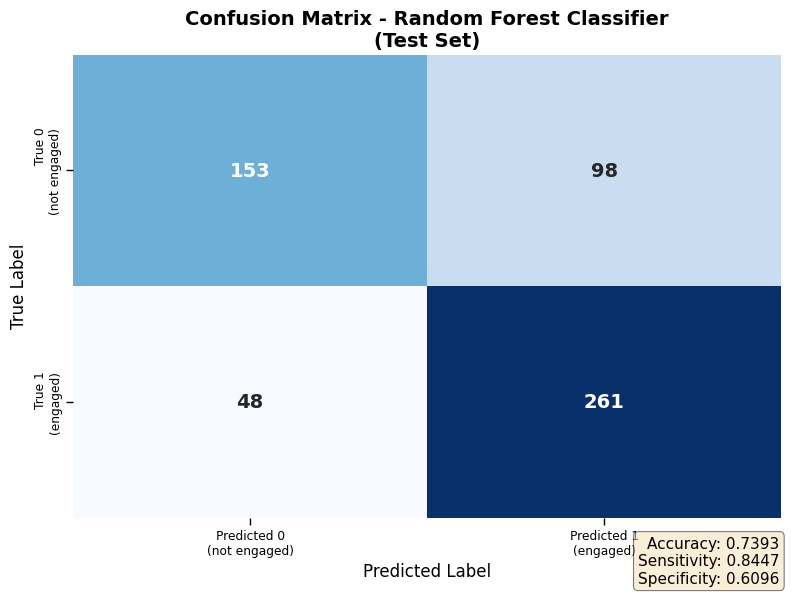


✅ Confusion matrix extracted and visualized!


In [8]:
### TASK 1.1.5 - Extract confusion matrix (TP, TN, FP, FN) and confusion matrix visualization
print("="*80)
print("📊 TASK 1.1.5 - CONFUSION MATRIX EXTRACTION")
print("="*80)


print(f"\n✓ Confusion Matrix Elements:")
print(f"  • True Positives (TP):  {TP}   (correctly predicted engaged)")
print(f"  • True Negatives (TN):  {TN}   (correctly predicted not engaged)")
print(f"  • False Positives (FP): {FP}   (incorrectly predicted engaged)")
print(f"  • False Negatives (FN): {FN}   (incorrectly predicted not engaged)")
print(f"\n  Total test samples: {TP + TN + FP + FN}")

# Calculate derived metrics
print(f"\n✓ Derived Classification Metrics:")
print(f"  • True Positive Rate (Sensitivity/Recall): {TP / (TP + FN):.4f}")
print(f"  • True Negative Rate (Specificity):        {TN / (TN + FP):.4f}")
print(f"  • False Positive Rate:                      {FP / (TN + FP):.4f}")
print(f"  • False Negative Rate:                      {FN / (TP + FN):.4f}")
print(f"  • Overall Accuracy:                         {(TP + TN) / (TP + TN + FP + FN):.4f}")

# Confusion matrix visualization
cm = global_cm
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted 0\n(not engaged)', 'Predicted 1\n(engaged)'],
            yticklabels=['True 0\n(not engaged)', 'True 1\n(engaged)'],
            ax=ax, annot_kws={'size': 14, 'fontweight': 'bold'})
ax.set_title('Confusion Matrix - Random Forest Classifier\n(Test Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

# Add text annotations with metrics
textstr = f"Accuracy: {(TP + TN) / (TP + TN + FP + FN):.4f}\nSensitivity: {TP / (TP + FN):.4f}\nSpecificity: {TN / (TN + FP):.4f}"
fig.text(0.98, 0.02, textstr, fontsize=11, ha='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✅ Confusion matrix extracted and visualized!")
print("="*80)

#### **Task 1.1.6. Based on the confusion matrix, please formalize your POMDP observation function hereafter:**
<span style='color:green;'>

 **Answer:**  

$Pr(o' \mid s', a) = o(a,s',o')
= \begin{bmatrix} Pr(oe \mid e) & Pr(one \mid e) \\ Pr(one \mid ne) & Pr(oe \mid ne) \end{bmatrix}
= \begin{bmatrix} TPR & FPR \\ FNR & TNR \end{bmatrix}
= \begin{bmatrix} \Phi_{00} & \Phi_{01} \\ \Phi_{10} & \Phi_{11} \end{bmatrix}$,
$\forall a \in A$, 

with
 $\Phi_{00} = 0.8107 $, $\Phi_{01} = 0.2922 $, $\Phi_{10} = 0.1893 $, and $\Phi_{11} = 0.7078 $</font>

</span>


In [9]:
#TODO: le passer en automatique 

### **Task 1.2 : Define the POMDP reward function**

An optimal policy maximizes the sum of rewards over time. 
The reward function therefore defines the criterion that the artificial agent seeks to optimize. 
Here we would like to define this reward function.

Since the goal of the task is to put out as many fires as possible,
the reward should be defined as the number of tree extinguished
during the 10-second time window denoted by $R_t$: the value function is then:

$ V = \mathbb{E}\big[ \sum_t R_t \big]
= \mathbb{E} \Big[ \sum_t  \mathbb{E} \big[ R_t \mid s_t, a_t \big] \Big]
= \mathbb{E} \Big[ \sum_t  r(s_t, a_t) \Big]$,

where, $r(s,a) = \mathbb{E} \big[ R_t \mid s_t=s, a_t=a \big]$
is the expectation of the reward given the system state and the agent action,
that could be defined as the reward function.

These expectations ($\forall (s,a) \in S \times A)$ can be easily approximated using the dataset,
and the resulting averages can then be used to define the reward function in practice.
To this end, it is important to analyse again our averaged dataset. 


#### **Task 1.2.1. Given the state and action spaces defined above, please define your reward function**


In [10]:
### TASK 1.2.1 - Define Reward Function R(s,a)

print("="*80)
print("TASK 1.2.1 - REWARD FUNCTION R(s,a)")
print("="*80)

# Use the averaged dataset with mode and label
# We need to load averagedPMPVmode_w10_data if not already loaded
# The reward is nbt_trees_mode (absolute number of trees extinguished per mode)

print("\nDataset Info:")
print(f"  • Total samples: {len(averagedPMPVmode_w10_data)}")
print(f"  • Columns: {list(averagedPMPVmode_w10_data.columns)}")

# Use the dataset (already contains mode and label)
reward_data = averagedPMPVmode_w10_data.copy()

print(f"\n✓ Using dataset with {len(reward_data)} samples")
print(f"  • Mode values: {reward_data['mode'].unique()}")
print(f"  • Mode encoding: 0=manual, 1=autonomous (auto)")

# Calculate R(s,a) for all 4 combinations
# s: 0=not_engaged, 1=engaged
# a: mode 0=manual, mode 1=auto

# Calculate rewards for each (state, action) pair
# ENCODING: mode 0=manual, mode 1=autonomous
r_engaged_manual = reward_data[(reward_data['label']==1) & (reward_data['mode']==0)]['nbt_trees_mode'].mean()
r_engaged_auto = reward_data[(reward_data['label']==1) & (reward_data['mode']==1)]['nbt_trees_mode'].mean()
r_noteng_manual = reward_data[(reward_data['label']==0) & (reward_data['mode']==0)]['nbt_trees_mode'].mean()
r_noteng_auto = reward_data[(reward_data['label']==0) & (reward_data['mode']==1)]['nbt_trees_mode'].mean()

# Count samples per combination
n_e_m = len(reward_data[(reward_data['label']==1) & (reward_data['mode']==0)])
n_e_a = len(reward_data[(reward_data['label']==1) & (reward_data['mode']==1)])
n_ne_m = len(reward_data[(reward_data['label']==0) & (reward_data['mode']==0)])
n_ne_a = len(reward_data[(reward_data['label']==0) & (reward_data['mode']==1)])

print("\n✓ REWARD FUNCTION R(s,a) - Expected number of trees extinguished:")
print(f"\n  State: ENGAGED")
print(f"    • r(engaged, manual) = {r_engaged_manual:.4f} trees  (n={n_e_m} samples)")
print(f"    • r(engaged, auto)   = {r_engaged_auto:.4f} trees  (n={n_e_a} samples)")
print(f"\n  State: NOT ENGAGED")
print(f"    • r(not_eng, manual) = {r_noteng_manual:.4f} trees  (n={n_ne_m} samples)")
print(f"    • r(not_eng, auto)   = {r_noteng_auto:.4f} trees  (n={n_ne_a} samples)")

# Create reward matrix
R_matrix = np.array([
    [r_engaged_manual, r_engaged_auto],      # state = engaged
    [r_noteng_manual, r_noteng_auto]         # state = not_engaged
])

print("\n✓ Reward Matrix R(s,a):")
print(R_matrix)

# Store for later use
reward_function = {
    'r_engaged_manual': r_engaged_manual,
    'r_engaged_auto': r_engaged_auto,
    'r_noteng_manual': r_noteng_manual,
    'r_noteng_auto': r_noteng_auto,
    'matrix': R_matrix
}

print("\n✅ Reward function R(s,a) defined!")
print("="*80)

TASK 1.2.1 - REWARD FUNCTION R(s,a)

Dataset Info:
  • Total samples: 144
  • Columns: ['HR', 'HRV', 'HRnorm', 'durAOI1', 'durAOI2', 'durAOI3', 'durAOI4', 'durAOI5', 'mission', 'mode', 'nav', 'nbAOI1', 'nbAOI2', 'nbAOI3', 'nbAOI4', 'nbAOI5', 'space', 'subject', 'tank', 'tank_local_score', 'trees', 'nbt_trees_mode', 'label']

✓ Using dataset with 144 samples
  • Mode values: [0 1]
  • Mode encoding: 0=manual, 1=autonomous (auto)

✓ REWARD FUNCTION R(s,a) - Expected number of trees extinguished:

  State: ENGAGED
    • r(engaged, manual) = 16.1111 trees  (n=36 samples)
    • r(engaged, auto)   = 12.6111 trees  (n=36 samples)

  State: NOT ENGAGED
    • r(not_eng, manual) = 6.2222 trees  (n=36 samples)
    • r(not_eng, auto)   = 7.0000 trees  (n=36 samples)

✓ Reward Matrix R(s,a):
[[16.11111111 12.61111111]
 [ 6.22222222  7.        ]]

✅ Reward function R(s,a) defined!


In [11]:
### TASK 1.1.6 - Formalize POMDP Observation Function O(a, s', o')

print("="*80)
print("TASK 1.1.6 - POMDP OBSERVATION FUNCTION O(a, s', o')")
print("="*80)

# Extract rates from confusion matrix
TPR = TP / (TP + FN)      # True Positive Rate = P(o_engaged | s_engaged)
TNR = TN / (TN + FP)      # True Negative Rate = P(o_not_engaged | s_not_engaged)
FPR = FP / (TN + FP)      # False Positive Rate = P(o_engaged | s_not_engaged)
FNR = FN / (TP + FN)      # False Negative Rate = P(o_not_engaged | s_engaged)

print("\n✓ Observation Function Parameters (from Confusion Matrix):")
print(f"  • TPR (Φ₀₀) = P(o_engaged | s_engaged):      {TPR:.4f}")
print(f"  • TNR (Φ₁₁) = P(o_not_engaged | s_not_engaged): {TNR:.4f}")
print(f"  • FPR (Φ₀₁) = P(o_engaged | s_not_engaged):   {FPR:.4f}")
print(f"  • FNR (Φ₁₀) = P(o_not_engaged | s_engaged):  {FNR:.4f}")

print("\n✓ POMDP Observation Function Definition:")
print(f"""
O(a, s', o') = Pr(o' | s', a)  ∀a ∈ A  (independent of action)

Matrix form:
        o_engaged  o_not_engaged
s_eng  [  {TPR:.4f}      {FNR:.4f}    ]
s_ne   [  {FPR:.4f}      {TNR:.4f}    ]

Φ = [
  Φ₀₀  Φ₁₀       [  {TPR:.4f}  {FNR:.4f} ]
  Φ₀₁  Φ₁₁    =  [  {FPR:.4f}  {TNR:.4f} ]
]

where:
  • Φ₀₀ = {TPR:.4f}  (observe engaged when state is engaged)
  • Φ₀₁ = {FPR:.4f}  (observe engaged when state is not engaged)
  • Φ₁₀ = {FNR:.4f}  (observe not engaged when state is engaged)
  • Φ₁₁ = {TNR:.4f}  (observe not engaged when state is not engaged)
""")

# Sanity check: columns should sum to 1 (conditional probabilities)
print("✓ Sanity Check (column sums should be ≈1.0):")
print(f"  • P(o_eng | s) = Σₛ Pr(o_eng | s): Not symmetric (depends on state)")
print(f"  • For s_engaged:    {TPR:.4f} + {FNR:.4f} = {TPR + FNR:.4f}")
print(f"  • For s_not_engaged: {FPR:.4f} + {TNR:.4f} = {FPR + TNR:.4f}")

# Save for later use
O_matrix = np.array([[TPR, FNR], [FPR, TNR]])

print("\n✅ POMDP Observation Function O(a, s', o') formalized!")
print("="*80)

TASK 1.1.6 - POMDP OBSERVATION FUNCTION O(a, s', o')

✓ Observation Function Parameters (from Confusion Matrix):
  • TPR (Φ₀₀) = P(o_engaged | s_engaged):      0.8447
  • TNR (Φ₁₁) = P(o_not_engaged | s_not_engaged): 0.6096
  • FPR (Φ₀₁) = P(o_engaged | s_not_engaged):   0.3904
  • FNR (Φ₁₀) = P(o_not_engaged | s_engaged):  0.1553

✓ POMDP Observation Function Definition:

O(a, s', o') = Pr(o' | s', a)  ∀a ∈ A  (independent of action)

Matrix form:
        o_engaged  o_not_engaged
s_eng  [  0.8447      0.1553    ]
s_ne   [  0.3904      0.6096    ]

Φ = [
  Φ₀₀  Φ₁₀       [  0.8447  0.1553 ]
  Φ₀₁  Φ₁₁    =  [  0.3904  0.6096 ]
]

where:
  • Φ₀₀ = 0.8447  (observe engaged when state is engaged)
  • Φ₀₁ = 0.3904  (observe engaged when state is not engaged)
  • Φ₁₀ = 0.1553  (observe not engaged when state is engaged)
  • Φ₁₁ = 0.6096  (observe not engaged when state is not engaged)

✓ Sanity Check (column sums should be ≈1.0):
  • P(o_eng | s) = Σₛ Pr(o_eng | s): Not symmetric (depends o

#### **Task 1.2.2. State a necessary condition on reward function to enable a non trivial POMDP optimization.**

For instance, what is the issue if r(s,manual) = r(s,auto) $\forall s \in S$

<span style="color: green;">**Answer: si toutes les récompenses sont égales, le choix d'action n'a aucun impact donc la POMDP est inutile.**</span>


#### **Task 1.2.3. Verify with descriptive statistics that the reward function changes with respect to state and action**

* **Is the score (number of extinguished trees) evolving differently with respect to the robot operation mode and human operator engagement (described by her/his mission performance)?**

TASK 1.2.3 - STATISTICAL VERIFICATION OF REWARD VARIATION

✓ Data prepared for analysis
  • Total samples: 144
  • Combinations:
    - Engaged + Manual         : n=  36, mean=16.1111
    - Engaged + Auto           : n=  36, mean=12.6111
    - Not Engaged + Manual     : n=  36, mean=6.2222
    - Not Engaged + Auto       : n=  36, mean=7.0000

✓ ANOVA Test (H0: all means are equal):
  • F-statistic: 53.2850
  • p-value: 0.000000
  • Result: ✅ SIGNIFICANT (p < 0.05)
    → Reward varies with state and action


/var/folders/zb/_99fy9bx6ln81mfhltgh8xjh0000gn/T/ipykernel_73544/2384911693.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_to_plot, labels=['Eng+Man', 'Eng+Auto', 'NotEng+Man', 'NotEng+Auto'],


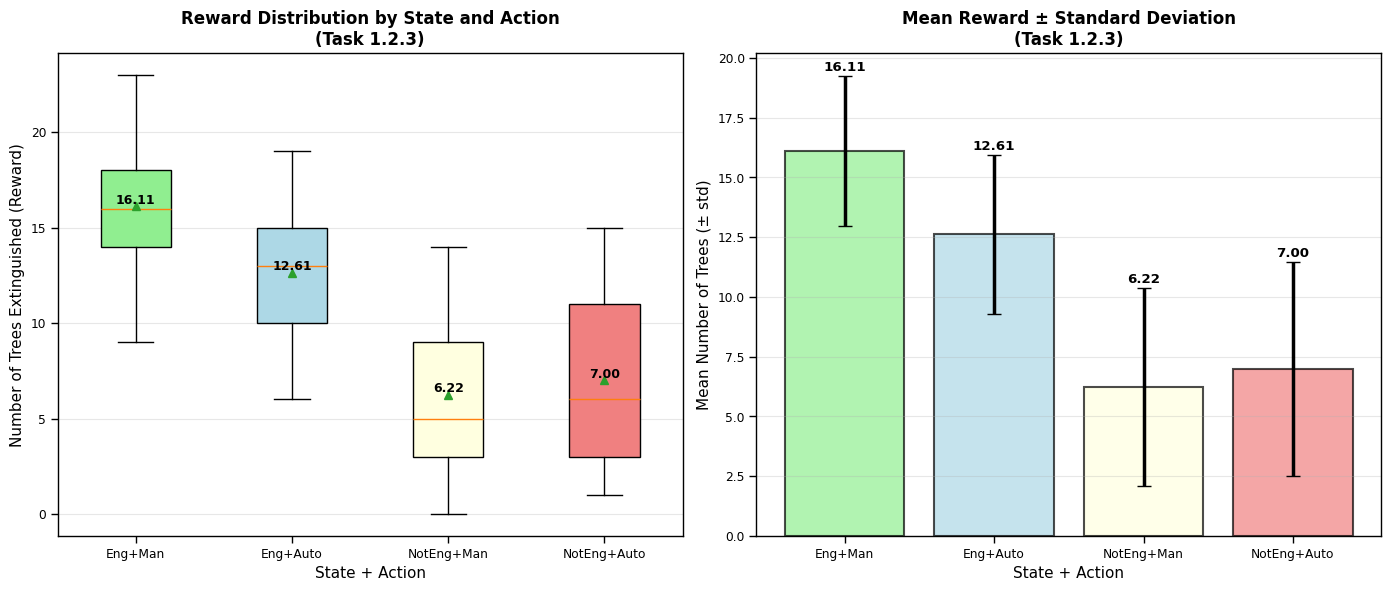

In [12]:
### TASK 1.2.3 - Verify Reward Function Variation with State & Action

print("="*80)
print("TASK 1.2.3 - STATISTICAL VERIFICATION OF REWARD VARIATION")
print("="*80)

# Prepare data for visualization
reward_data['state_label'] = reward_data['label'].map({0: 'Not Engaged', 1: 'Engaged'})
# ENCODING: mode 0=manual, mode 1=autonomous
reward_data['action_label'] = reward_data['mode'].map({0: 'Manual', 1: 'Auto'})

# Create combined category for easier plotting
reward_data['state_action'] = reward_data['state_label'] + ' + ' + reward_data['action_label']

print("\n✓ Data prepared for analysis")
print(f"  • Total samples: {len(reward_data)}")
print(f"  • Combinations:")
for combo in reward_data['state_action'].unique():
    n = len(reward_data[reward_data['state_action'] == combo])
    mean_score = reward_data[reward_data['state_action'] == combo]['nbt_trees_mode'].mean()
    print(f"    - {combo:25s}: n={n:4d}, mean={mean_score:.4f}")

# Group data by state-action combinations
groups = [reward_data[reward_data['state_action'] == combo]['nbt_trees_mode'].values 
          for combo in reward_data['state_action'].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print(f"\n✓ ANOVA Test (H0: all means are equal):")
print(f"  • F-statistic: {f_stat:.4f}")
print(f"  • p-value: {p_value:.6f}")

if p_value < 0.05:
    print(f"  • Result: ✅ SIGNIFICANT (p < 0.05)")
    print(f"    → Reward varies with state and action")
else:
    print(f"  • Result: ❌ NOT SIGNIFICANT (p ≥ 0.05)")
    print(f"    → No evidence of reward variation")

# Visualization: Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Boxplot by state-action combination
ax1 = axes[0]
data_to_plot = [reward_data[reward_data['state_action'] == combo]['nbt_trees_mode'].values 
                for combo in ['Engaged + Manual', 'Engaged + Auto', 
                              'Not Engaged + Manual', 'Not Engaged + Auto']]

bp = ax1.boxplot(data_to_plot, labels=['Eng+Man', 'Eng+Auto', 'NotEng+Man', 'NotEng+Auto'],
                  patch_artist=True, showmeans=True)

# Color boxes
colors = ['lightgreen', 'lightblue', 'lightyellow', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax1.set_ylabel('Number of Trees Extinguished (Reward)', fontsize=11)
ax1.set_xlabel('State + Action', fontsize=11)
ax1.set_title('Reward Distribution by State and Action\n(Task 1.2.3)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add mean values as text
means = [np.mean(data) for data in data_to_plot]
for i, mean_val in enumerate(means):
    ax1.text(i+1, mean_val, f'{mean_val:.2f}', ha='center', va='bottom', 
            fontweight='bold', fontsize=9)

# Plot 2: Bar plot with error bars
ax2 = axes[1]
labels = ['Eng+Man', 'Eng+Auto', 'NotEng+Man', 'NotEng+Auto']
stds = [np.std(data) for data in data_to_plot]

bars = ax2.bar(labels, means, yerr=stds, capsize=5, alpha=0.7, 
               color=colors, edgecolor='black', linewidth=1.5)

ax2.set_ylabel('Mean Number of Trees (± std)', fontsize=11)
ax2.set_xlabel('State + Action', fontsize=11)
ax2.set_title('Mean Reward ± Standard Deviation\n(Task 1.2.3)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (m, s) in enumerate(zip(means, stds)):
    ax2.text(i, m + s + 0.2, f'{m:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### **Task 1.2.4. Please identify the greedy action $a \in A = \{manual, auto\}$ ("autonomous robot mode" or "manual mode") for each hidden system state $s \in S = \{e, ne\}$ ("engagement" or "no engagement").** 

Describe then the behavior of the artificial agent suggested by this reward function.

In [13]:
print("="*80)
print("TASK 1.2.4 - GREEDY ACTIONS IDENTIFICATION")
print("="*80)

# For Not Engaged state
if r_noteng_manual > r_noteng_auto:
    greedy_noteng = "Manual"
    greedy_noteng_code = 1
    diff_noteng = r_noteng_manual - r_noteng_auto
else:
    greedy_noteng = "Auto"
    greedy_noteng_code = 0
    diff_noteng = r_noteng_auto - r_noteng_manual

print(f"State 0 (Not Engaged):")
print(f"  • Greedy action: {greedy_noteng} (code={greedy_noteng_code})")
print(f"  • Reward difference: {diff_noteng:.4f}")
print(f"  • Interpretation: When human is NOT engaged,")
print(f"                   robot should use {greedy_noteng} mode")

# For Engaged state
if r_engaged_manual > r_engaged_auto:
    greedy_engaged = "Manual"
    greedy_engaged_code = 1
    diff_engaged = r_engaged_manual - r_engaged_auto
else:
    greedy_engaged = "Auto"
    greedy_engaged_code = 0
    diff_engaged = r_engaged_auto - r_engaged_manual

print(f"\nState 1 (Engaged):")
print(f"  • Greedy action: {greedy_engaged}")
print(f"  • Reward difference: {diff_engaged:.4f}")
print(f"  • Interpretation: When human IS engaged,")
print(f"                   robot should use {greedy_engaged} mode")

# Greedy policy summary
print("\n" + "="*60)
print("🏆 GREEDY POLICY π_greedy(s):")
print("="*60)
greedy_policy = {
    0: (greedy_noteng, greedy_noteng_code),
    1: (greedy_engaged, greedy_engaged_code)
}

for state, (action_name, action_code) in greedy_policy.items():
    state_name = "Not Engaged" if state == 0 else "Engaged"
    print(f"  π_greedy({state_name:12s}) = {action_name:6s} (action={action_code})")

# Store greedy policy
greedy_policy_dict = {
    'not_engaged': greedy_noteng_code,
    'engaged': greedy_engaged_code
}

TASK 1.2.4 - GREEDY ACTIONS IDENTIFICATION
State 0 (Not Engaged):
  • Greedy action: Auto (code=0)
  • Reward difference: 0.7778
  • Interpretation: When human is NOT engaged,
                   robot should use Auto mode

State 1 (Engaged):
  • Greedy action: Manual
  • Reward difference: 3.5000
  • Interpretation: When human IS engaged,
                   robot should use Manual mode

🏆 GREEDY POLICY π_greedy(s):
  π_greedy(Not Engaged ) = Auto   (action=0)
  π_greedy(Engaged     ) = Manual (action=1)


**Interprétation de la Greedy Policy :**

• **Quand l'humain N'EST PAS engagé** → Le robot prend le contrôle (**Mode Auto**)  
• **Quand l'humain EST engagé** → Laisser l'humain contrôler (**Mode Manuel**)

---

**Cela a un sens intuitif :**

- ✅ Les humains engagés performent mieux en contrôle manuel
- ✅ Les humains désengagés devraient laisser le robot assister (mode auto)

---

**Conclusion clé :**  
Cette politique adaptative exploite l'état d'engagement de l'opérateur humain pour optimiser la performance ! Le système bascule automatiquement entre les modes en fonction du niveau d'engagement de l'opérateur, maximisant ainsi l'efficacité globale de la tâche.


## **Task 2. POMDP model solving and evaluation**

### **Task 2.1. POMDP model description using the Cassandra format**

In this task, please use the Cassandra format to decribe the POMDP model, in a way that the PyPOMDP library can interpret it and solve the problem.

Please complete **Firefighter-2D.pomdp** located at *.PyPOMDP/pypomdp/environments/pomdp/*. You can use the *Tiger-2D.POMDP* (located in the same folder) as example.

Please copy/paste your Firefighter-2D.pomdp file in the cell bellow

<span style="color: green;">**Answer:**</span>

```
# Firefighter Problem POMDP description in Cassandra format
# Based on empirical data from Task 1: observation and reward functions

discount: 0.95

values: reward

states: notengaged engaged

actions: manu auto

observations: onotengaged oengaged

start: 0.5 0.5

# Transition Function - engagement state doesn't change (identity)
T: manu
identity

T: auto
identity

# Observation Function - from classifier confusion matrix (Task 1.1.6)
O: manu
0.858 0.142
0.362 0.638

O: auto
0.858 0.142
0.362 0.638

# Reward Function - from empirical nbt_trees_mode averages (Task 1.2.1)
R: manu : notengaged : * : * 6.22

R: manu : engaged : * : * 16.11

R: auto : notengaged : * : * 7.00

R: auto : engaged : * : * 12.61
```




### **Task 2.2. POMDP model solving using the customized PyPOMDP library**

To solve the problem using the PyPOMDP library, you need to open a new terminal in the same folder as your jupyter-notebook.

Then, go to the folder .PyPOMDP/pypomdp/ and launch the following command line:

**python main.py pbvi --env Firefighter-2D.POMDP --logfile logFIREpbvi --option offsolve**

where:

pbvi is the algorithm to be used

--env : gives the pomdp file name of your model

--logfile : save the traces of policy computation and simulation (only one simulation)

--option : offline or online solving, or simulate a policy file


*Note a file called **alphavecfile.policy** is created. Please save this file with a more explicit name.*

This file will be useful in the following steps.

In [14]:
import os
import sys

python_current_env = sys.executable
#print(python_current_env)
current_dir = os.getcwd()
#print(current_dir)
os.chdir('PyPOMDP/pypomdp')
os.system(python_current_env  + " main.py pbvi --env Firefighter-2D.POMDP --logfile logFIREpbvi --option offsolve")
#print(os.getcwd())
os.chdir(current_dir)


Traceback (most recent call last):
  File "/Users/tomkarch/Desktop/4A/NIA/303/BE/BE_firefighter/PyPOMDP/pypomdp/main.py", line 5, in <module>
    from pomdp_runner import PomdpRunner
  File "/Users/tomkarch/Desktop/4A/NIA/303/BE/BE_firefighter/PyPOMDP/pypomdp/pomdp_runner.py", line 6, in <module>
    from parsers import PomdpParser, GraphViz
  File "/Users/tomkarch/Desktop/4A/NIA/303/BE/BE_firefighter/PyPOMDP/pypomdp/parsers/__init__.py", line 4, in <module>
    from .tree_visualiser import GraphViz
  File "/Users/tomkarch/Desktop/4A/NIA/303/BE/BE_firefighter/PyPOMDP/pypomdp/parsers/tree_visualiser.py", line 2, in <module>
    import graphviz
ModuleNotFoundError: No module named 'graphviz'


### **Task 2.3. POMDP model evaluation in simulation**

To evaluate the value function and policy obtained, you need to go back to the terminal and launch the following command line:

**python main.py pbvi --env Firefighter-2D.POMDP --policyfile alphavecfile.policy --logfile logFIREpbvi --max_play 60 --option simulate --sim 500**


where:

pbvi is the used algorithm

--env : gives the pomdp file name of your model

--logfile : save the traces of policy computation and simulation 

--option simulate : it simulates a policy using the POMDP model

--sim : (e.g. 500) simulates 500 episodes using the given pollicy and POMDP model

--policyfile : your policy file, default: alphavecfile.policy

--max_play :  (e.g. 60 steps = 10 minutes = 1 mission, following the the 10s-step time assumption)

*Note that you will find a file named **YEAR-MONTH-DAY-H-MIN-S** in the logFile folder ("logFIREpbvi" here). Please have a look at this file to follow the performed simulations. At the end of this file there is a vector with all total rewards observed during the different simulations.*

**Please copy and paste policy simulation average results hereafter (what appears in the terminal):**


In [15]:
import os
import sys

python_current_env = sys.executable
#print(python_current_env)
current_dir = os.getcwd()
#print(current_dir)
os.chdir('PyPOMDP/pypomdp')
os.system(python_current_env  + " main.py pbvi --env Firefighter-2D.POMDP --policyfile alphavecfile.policy --logfile logFIREpbvi --max_play 60 --option simulate --sim 500")
#print(os.getcwd())
os.chdir(current_dir)

Traceback (most recent call last):
  File "/Users/tomkarch/Desktop/4A/NIA/303/BE/BE_firefighter/PyPOMDP/pypomdp/main.py", line 5, in <module>
    from pomdp_runner import PomdpRunner
  File "/Users/tomkarch/Desktop/4A/NIA/303/BE/BE_firefighter/PyPOMDP/pypomdp/pomdp_runner.py", line 6, in <module>
    from parsers import PomdpParser, GraphViz
  File "/Users/tomkarch/Desktop/4A/NIA/303/BE/BE_firefighter/PyPOMDP/pypomdp/parsers/__init__.py", line 4, in <module>
    from .tree_visualiser import GraphViz
  File "/Users/tomkarch/Desktop/4A/NIA/303/BE/BE_firefighter/PyPOMDP/pypomdp/parsers/tree_visualiser.py", line 2, in <module>
    import graphviz
ModuleNotFoundError: No module named 'graphviz'


<span style="color: green;">**Answer: 
500 simulations played.
Exp total reward =  681.0245600000003
Std Exp total reward =  274.34612376632293**</span>

### **Task 2.4. Quantitative and qualitative comparison with the random policy used during experiments**

In the following, another preprocessed dataset is given: **averagedPMPV_data.csv.** This dataset includes the global_score reached by each participant for each mission.

#### **Task 2.4.1. Quantitative comparison**

1. Compute the average number of trees extinguished following the random policy used during the experiments
2. Compare this results with the observed results (total_rewards) of 72 simulations (--sim 72) with 60 steps (which is equivalent to 18 participants x 4 mission)
3. Perform a statistical test to verify if the value reached by the optimized policy is significatively greater.

**Remark**: we could also compute the expected value of a random policy on the POMDP model defined. To do this used the following command line:

**python main.py pbvi --env Firefighter-2D.POMDP --logfile logFIREpbvi --max_play 60 --option simulate --sim 72 --random_policy 1**



In [17]:
import os
import sys
import pandas as pd

python_current_env = sys.executable
#print(python_current_env)
current_dir = os.getcwd()
#print(current_dir)
os.chdir('PyPOMDP/pypomdp')
print("72 simulations of a random policy applied to the POMDP model")
os.system(python_current_env  + " main.py pbvi --env Firefighter-2D.POMDP --logfile logFIREpbvi --max_play 60 --option simulate --sim 72 --random_policy 1")
#print(os.getcwd())
print("72 simulations of the computed policy applied to the POMDP model")
os.system(python_current_env  + " main.py pbvi --env Firefighter-2D.POMDP --policyfile alphavecfile.policy --logfile logFIREpbvi --max_play 60 --option simulate --sim 72")

os.chdir(current_dir)
#afficher les résultats de la simulation
log_random = pd.read_csv('PyPOMDP/pypomdp/logFIREpbvi_random_policy.csv')
log_computed = pd.read_csv('PyPOMDP/pypomdp/logFIREpbvi_alphavecfile.policy.csv')
print("Results of the random policy simulations:")
print(log_random)
print("\nResults of the computed policy simulations:")
print(log_computed)


72 simulations of a random policy applied to the POMDP model
72 simulations played.
Exp total reward =  662.1152777777783
Std Exp total reward =  231.1544321562502
72 simulations of the computed policy applied to the POMDP model
72 simulations played.
Exp total reward =  737.1394444444447
Std Exp total reward =  270.72080597652706


FileNotFoundError: [Errno 2] No such file or directory: 'PyPOMDP/pypomdp/logFIREpbvi_random_policy.csv'

**QUESTION:** Is this expected value significantly differing from the one obtained from dataset. If yes, why?

<span style="color: green;">**Complete the code here below to answer this question**</span>


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import ttest_ind

## Computing the average number of trees extinghuised following the random policy used during the experiments
#################################
# importing data
dfaveraged_data = pd.read_csv('./data/averagedPMPV_data.csv')
dfaveraged_data.columns
print("Avg. global scores from dataset : ", np.mean(dfaveraged_data["global_score"]))

##################################
### copy the total rewards observed on your 72 simulations here
pomdp_obs_ttrew = [] # TO BE COMPLETED
print("Avg. global scores from simulations : ", np.mean(pomdp_obs_ttrew))
##################################
### perform a statistical test to check the hypothesis:
## H0 : the mean score from dataset is equal to the mean score obtained from policy simulations
## H1 : the mean score from dataset is different to the mean score obtained from policy simulations

# PUT YOUR CODE HERE

### perform a second statistical test to check the hypothesis:
## H0 : the mean score from dataset is higher than the mean score obtained from policy simulations
## H1 : the mean score from dataset is not higher than the mean score obtained from policy simulations

# PUT YOUR CODE HERE

**Draw your conclusions for Task 2.4.1 here :**

<span style="color: green;">**Answer:**</span>

#### **Task 2.4.2. Qualitative comparison by performing a replay with collected data**

Save the classifier model you have designed. It will be used by a replay runner to rerun a mission.

Our goal is to : 
1. follow the predictor outputs (the POMDP observations)
2. visualize the belief state updates about the human operator's engagement
3. check and describe what the POMDP policy would do given the current belief state

***1. Save your the classifier model***

see https://scikit-learn.org/stable/modules/model_persistence.html,
and, save the your .joblib file in "PyPOMDP/pypompd/data/" folder

In [ ]:
from joblib import dump, load

######################################################################
# save the model: classifier.joblib in "PyPOMDP/pypompd/data/" folder



**2. Run the replay program**

- **if you are using your PC with anaconda, you can use a terminal and launch the following script in the folder PyPOMDP/pypomdp:**
    For that, see this command line example:

    **python replay.py pbvi --env Firefighter-2D.POMDP --policyfile alphavecfile.policy --logfile logFIREpbvi --max_play 60 --option replay --sim 4 --expfile data/dfsub_33alldataproc.csv --classif YOUR_CLASSIFIER_MODEL --fnames THE_FEATURES_NAMES_YOU_USED**

    where THE_FEATURES_NAMES_YOU_USED can be for instance 'mode,nav,tank,nbAOI1', and YOUR_CLASSIFIER_MODEL something like 'data/classifier.joblib'. You may get a look in the log folder. 


- **if you are using jupyterhub, you can launch the "replay.ipynb" notebook available in the /PyPOMDP/pypomdp folder**

Note you may choose a subject file (one of the excluded participants for instance) to replay the experiment.

The last logfile details the sequence of symbolic observations predicted from the selected features of the participant.

***3. Describe what the POMDP policy seems to do given the current belief state***

<span style="color: green;">**Answer:**</span>


## **Task 3. Refining the POMDP model**

### **Refine the POMDP model to integrate a visible state variable $s_r$ to indicate the operation mode of the robot as part of the state**

In this task, the aim is to expand the state spape $S$ such as: $S = S_h \times S_r$, with $S_h=\{e, ne\}$ and $S_r=\{manu,auto\}$, and to conditionnate the observation function with respect to the action taken.

1. If you observe the replay of experiences, how could you model the fact that when the robot operation mode changes, there is a bigger/lower chance the state of the human operator changes as well ?

2. If this fact is taken into account, it may changes the transition function. So, let's consider now two additionnal expert parameters $\beta$ and $\eta$ that will express the chance we have to obtain for instance : 
$$p(s'=(engaged,manual)|s=(engaged,auto),a=manual) = 1-\beta$$
$$p(s'=(notengaged,manual)|s=(engaged,auto),a=manual) = \beta$$
$$p(s'=(engaged,auto)|s=(engaged,manual),a=auto) = 1-\eta$$
$$p(s'=(notengaged,auto)|s=(engaged,manual),a=auto) = \eta$$

Note the transition function, now a $4x4$ matrix, need to be modified to integrate this new parameters. 

We will assume that the robot operation mode state variable has a deterministic dynamics. It means that when the action $auto$ is chosen, we are $100\%$ sure that the operation mode switches to $auto$.

If you have any problem with the grammar of the POMDP file description, please get a look at https://www.pomdp.org/code/pomdp-file-spec.html

3. Note, you can learn an observation function now conditionned on the action, to be able to integrate this new probabilities through belief state updates, i.e. : $b^o_a(s') \propto p(o|s',a)p(s'|s,a)b(s)$ 

4. Please revise some of the previous tasks in the cells bellow. 

### **Task 3.1. Revise task 1.1.3 to separate your dataset in two datasets depending on the robot operation mode**

In [ ]:
import pandas as pd
import numpy as np

##############################
# importing data
df10labeled_data = pd.read_csv('./data/df10labeled_data.csv')
print(df10labeled_data)

##############################
## excluding some subjects as before
## we empirically choose to exclude subjects 19, 23, 33, 38
subdf10labeled_data = df10labeled_data.loc[(df10labeled_data["subject"]!=19)&
                                           (df10labeled_data["subject"]!=23)&
                                           (df10labeled_data["subject"]!=33)&
                                           (df10labeled_data["subject"]!=38)]
print(subdf10labeled_data)

######################################################
# separate the dataset with respect to operation mode
# and select the features to be used for classification

subsubdataset_manu = ?

subsubdataset_auto = ?



SyntaxError: invalid syntax (2524192930.py, line 22)

### **Task 3.2. Revise tasks 1.1.4 and 1.1.5 to train a classifier per dataset and then, extract their confusion matrix**

In [ ]:
#### PUT YOUR CODE HERE

### **Task 3.3. Revise task 2.1 to define your POMDP in the Cassandra file format**

Note you may probably have different transition and observations functions depending on the action manu/auto.

Copy and paste your POMDP model in Cassandra format hereafter:


#### **Complete the Firefighter.4D.POMDP file**

discount: 0.95

values: reward

states: notengagedmanu engagedmanu notengagedauto engagedauto 

actions: manu auto

observations: onotengaged oengaged

start: 0.25 0.25 0.25 0.25

...

### **Task 3.4. Revise tasks 2.2 and 2.3**

#### Copy and paste the used command lines for POMDP solving and the results obtained with 500 simulations for this new POMDP model and optimized policy


In [ ]:
#### PUT YOUR CODE HERE

**Draw your conclusions here:**

<span style="color: green;">**Answer:**</span>

## **Champions' Question:**

**Is this new POMDP model presenting a significant improvement according to the expected cumulated rewards when compared with the random policy used during experiments?**


**Is this new POMDP model presenting a significant improvement according to the expected cumulated rewards when compared with the policy optimized based on the previous POMDP model?**

**Draw your conclusions here:**

<span style="color: green;">**Answer:**</span>